In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('uci_cleaned_cc_approval.csv')
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [4]:
categorical_cols = ['Married', 'BankCustomer', 'Industry', 'Ethnicity', 'PriorDefault', 'Employed', 'DriversLicense','Citizen']

In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', one_hot_encoder, categorical_cols)
    ],
    remainder='passthrough'
)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Approved", axis=1)
y = df["Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Approved', axis=1)
y = df['Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.metrics import classification_report, accuracy_score

log_reg_pipeline.fit(X_train, y_train)
y_pred_log_reg = log_reg_pipeline.predict(X_test)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Performance:
Accuracy: 0.8261
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        68
           1       0.85      0.80      0.82        70

    accuracy                           0.83       138
   macro avg       0.83      0.83      0.83       138
weighted avg       0.83      0.83      0.83       138



In [10]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.8551
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        68
           1       0.87      0.84      0.86        70

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138



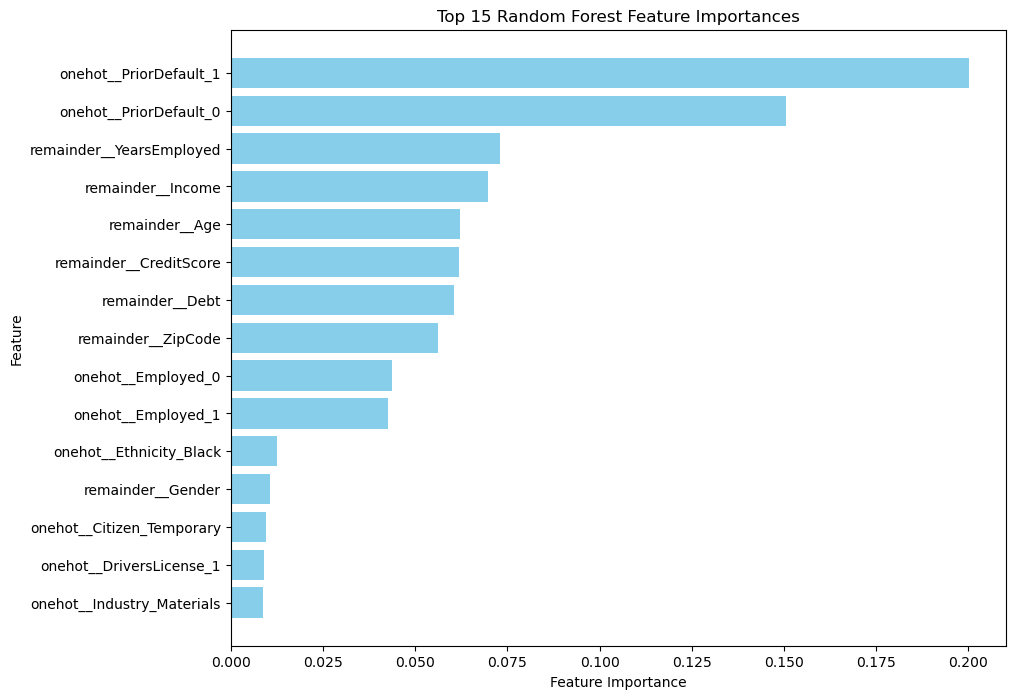

In [14]:
# Assuming rf_pipeline is fitted and 'classifier' is the Random Forest step name
rf_model = rf_pipeline.named_steps['classifier']

# Get feature names from the preprocessor output
# NOTE: This is complex because of the ColumnTransformer output
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importance scores
importances = rf_model.feature_importances_

# Create a DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15) # Show top 15

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importances')
plt.gca().invert_yaxis() # Highest importance on top
plt.show()

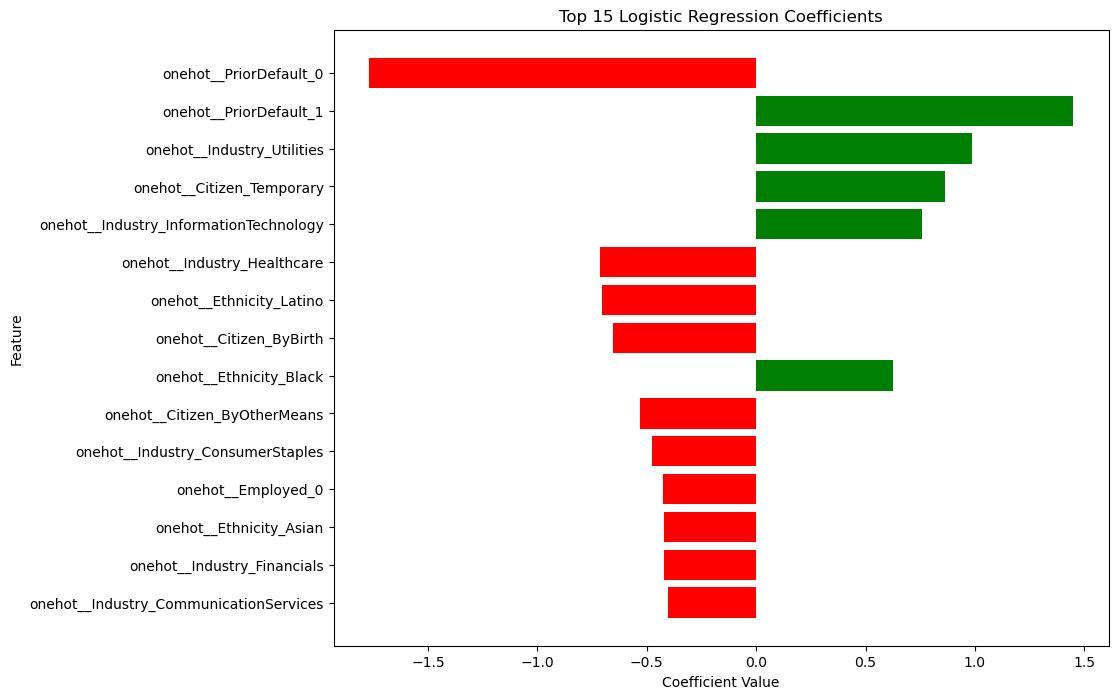

In [15]:
# Assuming log_reg_pipeline is fitted and 'classifier' is the Logistic Regression step name
log_reg_model = log_reg_pipeline.named_steps['classifier']

# Get feature names (same process as Random Forest)
feature_names = log_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = log_reg_model.coef_[0]

# Create a DataFrame for plotting
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=lambda x: abs(x), ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], 
         color=['red' if c < 0 else 'green' for c in coeff_df['Coefficient']])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 15 Logistic Regression Coefficients')
plt.gca().invert_yaxis()
plt.show()

In [16]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Approved' in numerical_cols:
    numerical_cols.remove('Approved') 

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

scaler = StandardScaler()
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

clustering_preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numerical_cols),     
        ('cat', one_hot_encoder, categorical_cols)
    ],
    remainder='passthrough'
)

X_processed = clustering_preprocessor.fit_transform(X)

C:\Users\rigel\anaconda3\envs\pic16b\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\rigel\anaconda3\envs\pic16b\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\rigel\anaconda3\envs\pic16b\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rigel\anaconda3\envs\pic16b\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\rigel\anaconda3\envs\pic16b\Lib\subprocess.py", line 1538

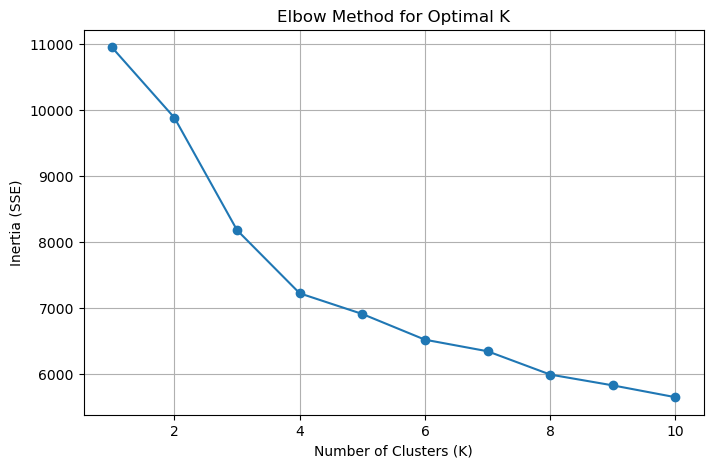

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve 
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.grid(True)
plt.show()

In [19]:
optimal_k = 3

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
final_kmeans.fit(X_processed)

df['Cluster'] = final_kmeans.labels_

C:\Users\rigel\anaconda3\envs\pic16b\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [20]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

n_components = 2 

pca_kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', clustering_preprocessor), 
    
    ('pca', PCA(n_components=n_components, random_state=42)),
    
    ('kmeans', KMeans(n_clusters=2, random_state=42, n_init='auto')) 
])

pca_kmeans_pipeline.fit(X)

cluster_labels_k2 = pca_kmeans_pipeline.named_steps['kmeans'].labels_

if isinstance(y, (np.ndarray, list)):
    y_series = pd.Series(y, name='True Class')
else:
    y_series = y.rename('True Class')


# --- 3. Create the Contingency Table ---
contingency_table = pd.crosstab(y_series, cluster_labels_k2, 
                                 rownames=['True Class'], 
                                 colnames=['K-Means Cluster'],
                                 margins=True)

print("--- Contingency Table (K-Means Clusters vs. True Labels) ---")
print(contingency_table)

ari_score = adjusted_rand_score(y_series, cluster_labels_k2)

print(f"\n--- Adjusted Rand Index (ARI) Score ---")
print(f"ARI: {ari_score:.4f}")

--- Contingency Table (K-Means Clusters vs. True Labels) ---
K-Means Cluster    0    1  All
True Class                    
0                265  118  383
1                260   47  307
All              525  165  690

--- Adjusted Rand Index (ARI) Score ---
ARI: 0.0048


C:\Users\rigel\anaconda3\envs\pic16b\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


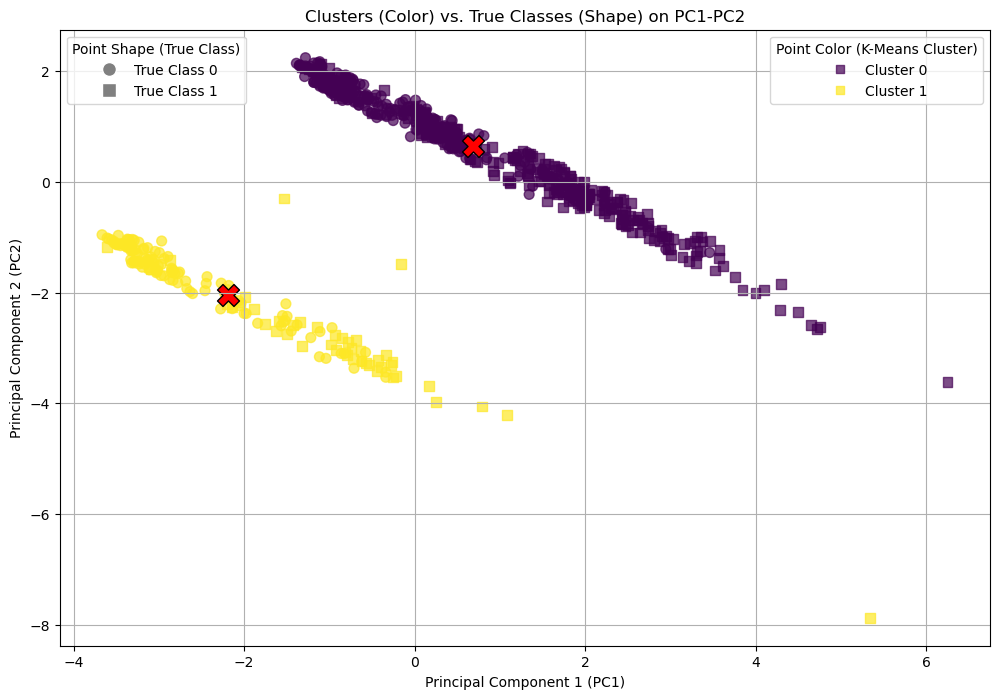

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

X_pca = pca_kmeans_pipeline.named_steps['pca'].transform(
    pca_kmeans_pipeline.named_steps['preprocessor'].transform(X)
)

cluster_labels = pca_kmeans_pipeline.named_steps['kmeans'].labels_

pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

pca_df['True_Class'] = y

markers = {0: 'o', 1: 's'} 

plt.figure(figsize=(12, 8))
scatter_handles = []

for true_class_label, marker_shape in markers.items():
    subset = pca_df[pca_df['True_Class'] == true_class_label]
    
    scatter = plt.scatter(
        subset['PC1'], 
        subset['PC2'], 
        c=subset['Cluster'], 
        cmap='viridis', 
        marker=marker_shape,
        alpha=0.7,
        s=50, 
        label=f'True Class {true_class_label}'
    )
    scatter_handles.append(scatter)


centroids = pca_kmeans_pipeline.named_steps['kmeans'].cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    marker='X', 
    s=250, 
    c='red', 
    label='Centroids',
    edgecolor='black'
)

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('Clusters (Color) vs. True Classes (Shape) on PC1-PC2')
plt.grid(True)

legend1 = plt.legend(
    handles=[plt.Line2D([0], [0], marker=markers[c], color='w', markerfacecolor='gray', markersize=10) for c in markers.keys()], 
    labels=[f'True Class {c}' for c in markers.keys()], 
    title="Point Shape (True Class)",
    loc="upper left"
)
plt.gca().add_artist(legend1)

cluster_labels_set = sorted(pca_df['Cluster'].unique())
legend2 = plt.legend(
    handles=scatter.legend_elements()[0], 
    labels=[f'Cluster {i}' for i in cluster_labels_set], 
    title="Point Color (K-Means Cluster)",
    loc="upper right"
)

plt.show()

C:\Users\rigel\anaconda3\envs\pic16b\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


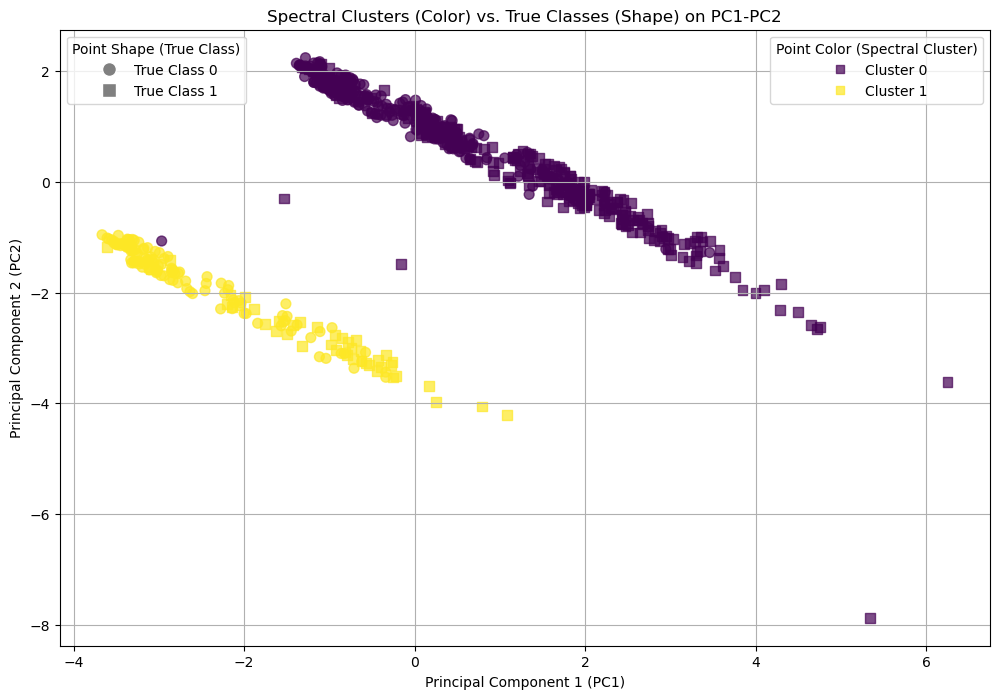


--- Spectral Clustering Evaluation ---
Spectral Cluster    0    1  All
True Class                     
0                 266  117  383
1                 263   44  307
All               529  161  690

Adjusted Rand Index (ARI): 0.0058


In [22]:
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Spectral Clustering (K=2) ---
# We use n_neighbors=10 and affinity='nearest_neighbors' as robust defaults.
# This step is run on the high-dimensional, preprocessed data (X_processed).
# NOTE: Spectral Clustering can be computationally expensive on large datasets.
sc_model = SpectralClustering(
    n_clusters=2, 
    random_state=42, 
    n_init=10, 
    affinity='nearest_neighbors', 
    n_neighbors=10
)

# Apply the preprocessor to the original data (X) to get the input array
X_processed = clustering_preprocessor.transform(X)
sc_labels = sc_model.fit_predict(X_processed)


# --- 2. Evaluation ---
# Create contingency table and calculate ARI, similar to the K-Means analysis.

y_series = pd.Series(y, name='True Class')

contingency_table_sc = pd.crosstab(y_series, sc_labels, 
                                    rownames=['True Class'], 
                                    colnames=['Spectral Cluster'],
                                    margins=True)

ari_score_sc = adjusted_rand_score(y_series, sc_labels)


# --- 3. PCA for Visualization ---
# We run PCA on the processed data to reduce it to 2 dimensions for plotting.
pca_viz = PCA(n_components=2, random_state=42)
X_pca_sc = pca_viz.fit_transform(X_processed)

# Create a DataFrame for plotting
pca_df_sc = pd.DataFrame(data = X_pca_sc, columns = ['PC1', 'PC2'])
pca_df_sc['Cluster'] = sc_labels
pca_df_sc['True_Class'] = y


markers = {0: 'o', 1: 's'} 

plt.figure(figsize=(12, 8))
scatter_handles = []

for true_class_label, marker_shape in markers.items():
    subset = pca_df_sc[pca_df_sc['True_Class'] == true_class_label]
    
    scatter = plt.scatter(
        subset['PC1'], 
        subset['PC2'], 
        c=subset['Cluster'], 
        cmap='viridis', 
        marker=marker_shape,
        alpha=0.7,
        s=50, 
        label=f'True Class {true_class_label}'
    )
    scatter_handles.append(scatter)

# --- Finalize Plot ---
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('Spectral Clusters (Color) vs. True Classes (Shape) on PC1-PC2')
plt.grid(True)

legend1 = plt.legend(
    handles=[plt.Line2D([0], [0], marker=markers[c], color='w', markerfacecolor='gray', markersize=10) for c in markers.keys()], 
    labels=[f'True Class {c}' for c in markers.keys()], 
    title="Point Shape (True Class)",
    loc="upper left"
)
plt.gca().add_artist(legend1)

# 2. Legend for Cluster Colors
cluster_labels_set = sorted(pca_df_sc['Cluster'].unique())
legend2 = plt.legend(
    handles=scatter.legend_elements()[0], 
    labels=[f'Cluster {i}' for i in cluster_labels_set], 
    title="Point Color (Spectral Cluster)",
    loc="upper right"
)

plt.show()

print("\n--- Spectral Clustering Evaluation ---")
print(contingency_table_sc)
print(f"\nAdjusted Rand Index (ARI): {ari_score_sc:.4f}")

In [23]:
max(df["CreditScore"].tolist())

67

In [24]:
sum(df["CreditScore"].tolist())/len(df["CreditScore"].tolist())

2.4

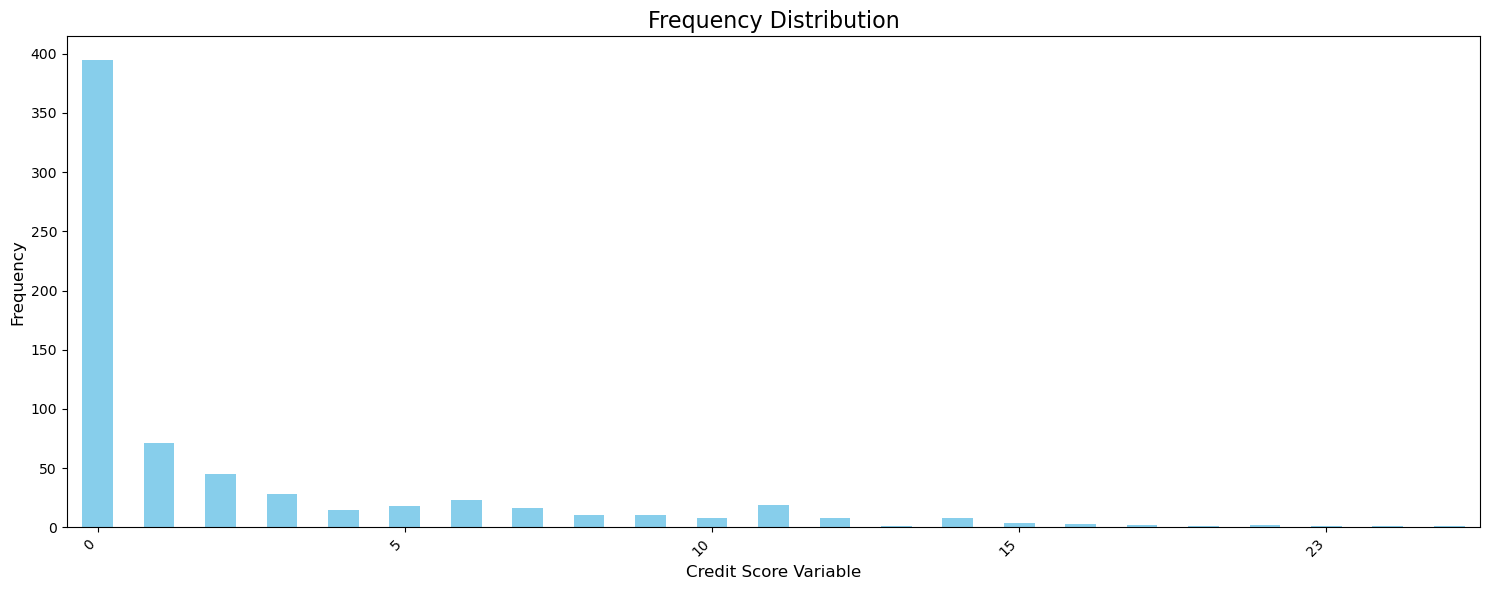

In [25]:
frequency_counts = pd.Series(df["CreditScore"].tolist()).value_counts().sort_index()

plt.figure(figsize=(15, 6))
frequency_counts.plot(kind='bar', color='skyblue')

plt.title('Frequency Distribution', fontsize=16)
plt.xlabel('Credit Score Variable', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

tick_step = 5
plt.xticks(
    ticks=np.arange(0, len(frequency_counts), step=tick_step),
    labels=frequency_counts.index[::tick_step],
    rotation=45,
    ha='right'
)
plt.tight_layout()

plt.show()

In [26]:
print(min(df["ZipCode"].tolist()))
print(max(df["ZipCode"].tolist()))

0
2000


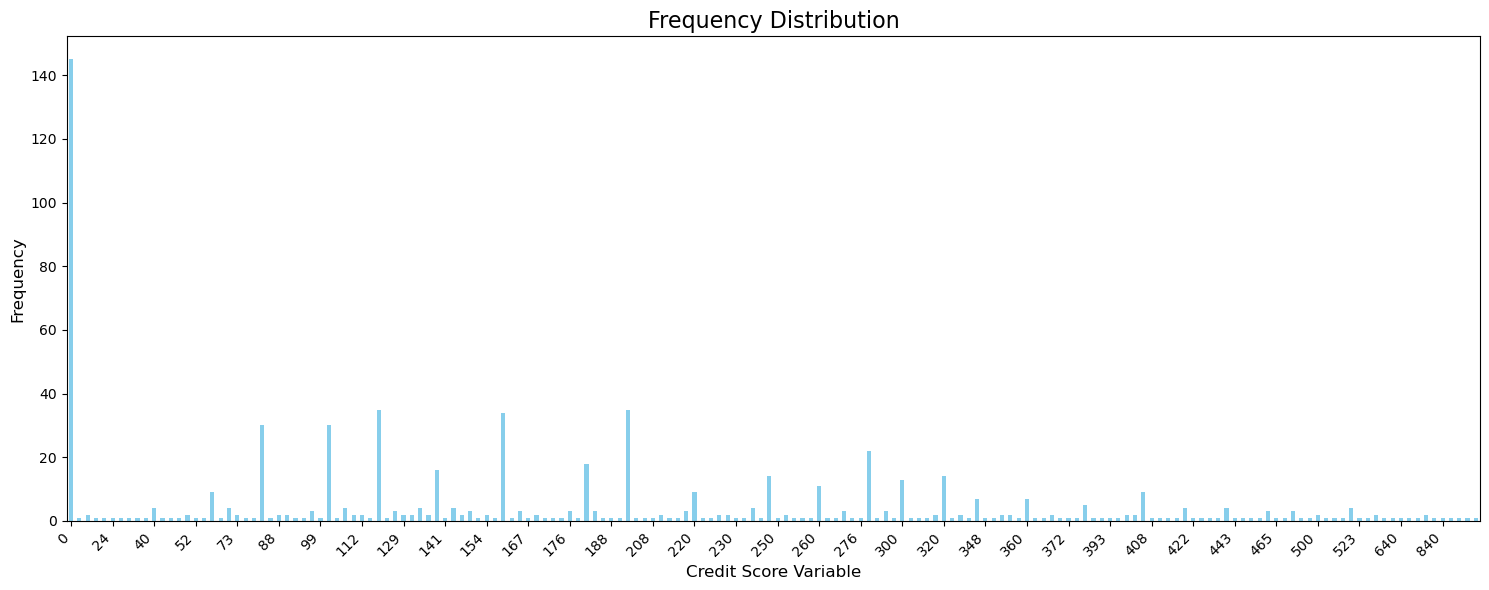

In [27]:
frequency_counts = pd.Series(df["ZipCode"].tolist()).value_counts().sort_index()

plt.figure(figsize=(15, 6))
frequency_counts.plot(kind='bar', color='skyblue')

plt.title('Frequency Distribution', fontsize=16)
plt.xlabel('Credit Score Variable', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

tick_step = 5
plt.xticks(
    ticks=np.arange(0, len(frequency_counts), step=tick_step),
    labels=frequency_counts.index[::tick_step],
    rotation=45,
    ha='right'
)
plt.tight_layout()

plt.show()